# 03 — Train Baseline (LoRA + Random Batching)

**Goal:** Train a baseline instruction-tuned model using standard random batching.

This notebook:
1. Loads `bootstrap_manifest.json` (Drive paths)
2. Loads dataset from Drive (default: `dolly_small_1k`)
3. Splits into train/eval deterministically
4. Tokenizes (cached to Drive)
5. Trains **LoRA** with HuggingFace Trainer
6. Saves:
   - adapter checkpoints
   - training metrics (`metrics.jsonl`)
   - final summary (`run_summary.json`)
   - plots (`loss_curve.png`)
   - `experiment_logs.csv` (row append style)

In [ ]:
import os
from google.colab import drive

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Google Drive already mounted.")

Mounted at /content/drive


In [ ]:
import os
import json
import time
import math
import random
from dataclasses import dataclass
from typing import Dict, Any, Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_from_disk, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)
from peft import LoraConfig, get_peft_model, TaskType

## 2) Load Manifest + Paths

In [ ]:
ROOT = "/content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research"
MANIFEST_PATH = f"{ROOT}/manifests/bootstrap_manifest.json"

if not os.path.exists(MANIFEST_PATH):
    raise FileNotFoundError(
        f"bootstrap_manifest.json not found at: {MANIFEST_PATH}\n"
        "Run 00_bootstrap_downloads.ipynb first."
    )

with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

DIRS = manifest["dirs"]

def _safe_makedirs(p: str):
    os.makedirs(p, exist_ok=True)

def _now_utc() -> str:
    return time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())

print("Loaded manifest created_at_utc:", manifest.get("created_at_utc"))
print("ROOT:", manifest.get("root", ROOT))

Loaded manifest created_at_utc: 2026-03-05T17:21:43Z
ROOT: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research


## Config

Baseline = LoRA + random batching.
Keep the *same* dataset/model/hparams later for grouped batching.

Notes:
- Start with `dolly_small_1k` for quick validation.
- Then scale to `dolly_15k`.

In [ ]:
# ---------- Experiment identity ----------
EXP_ID = "exp_003_baseline_random_lora"
METHOD = "random_lora"

# ---------- Dataset ----------
DATASET_NAME = "dolly_small_1k"   # "dolly_15k" later
SPLIT_NAME = "train"

# Dolly fields:
INSTRUCTION_FIELD = "instruction"
CONTEXT_FIELD = "context"     # may be empty
RESPONSE_FIELD = "response"

# ---------- Model ----------
BASE_MODEL_DIRNAME = "flan-t5-small"  # must exist in models/base_models/
BASE_MODEL_PATH = f"{DIRS['shared_models_base']}/{BASE_MODEL_DIRNAME}"

# ---------- Tokenization ----------
MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256

# ---------- Train/Eval split ----------
EVAL_RATIO = 0.1
SEED = 42

# ---------- Training ----------
EPOCHS = 20
PER_DEVICE_BATCH = 8
GRAD_ACCUM = 1
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.03
LOGGING_STEPS = 20
EVAL_STRATEGY = "steps"
EVAL_STEPS = 100
SAVE_STEPS = 100
SAVE_TOTAL_LIMIT = 3

# ---------- LoRA ----------
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# ---------- Caching ----------
CACHE_TOKENIZED = True

# ---------- Device ----------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("BASE_MODEL_PATH:", BASE_MODEL_PATH)

DEVICE: cuda
BASE_MODEL_PATH: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/models/base_models/flan-t5-small


## 4) Output directories (organized)

In [ ]:
RUN_ROOT = f"{DIRS['experiments']}/{EXP_ID}"
OUT_CHECKPOINTS = f"{RUN_ROOT}/checkpoints"
OUT_LOGS = f"{RUN_ROOT}/logs"
OUT_PLOTS = f"{RUN_ROOT}/plots"
OUT_TABLES = f"{RUN_ROOT}/tables"

for p in [RUN_ROOT, OUT_CHECKPOINTS, OUT_LOGS, OUT_PLOTS, OUT_TABLES]:
    _safe_makedirs(p)

RUN_MANIFEST_PATH = f"{RUN_ROOT}/run_manifest.json"
RUN_SUMMARY_PATH = f"{RUN_ROOT}/run_summary.json"
METRICS_JSONL_PATH = f"{OUT_LOGS}/metrics.jsonl"
LOSS_PLOT_PATH = f"{OUT_PLOTS}/loss_curve.png"

EXPERIMENT_CSV_PATH = f"{DIRS['experiments']}/experiment_logs/experiment_logs.csv"
_safe_makedirs(os.path.dirname(EXPERIMENT_CSV_PATH))

print("RUN_ROOT:", RUN_ROOT)
print("EXPERIMENT_CSV_PATH:", EXPERIMENT_CSV_PATH)

RUN_ROOT: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/exp_003_baseline_random_lora
EXPERIMENT_CSV_PATH: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/experiment_logs/experiment_logs.csv


## 5) Determinism (important)

In [ ]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## 6) Load dataset + deterministic split

We do a deterministic split so baseline and grouped runs evaluate identically.

In [ ]:
dataset_path = f"{DIRS['datasets_raw']}/{DATASET_NAME}"
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset not found: {dataset_path}")

ds = load_from_disk(dataset_path)
base = ds[SPLIT_NAME]

required = {INSTRUCTION_FIELD, RESPONSE_FIELD}
missing = [c for c in required if c not in base.column_names]
if missing:
    raise KeyError(f"Missing columns in dataset: {missing}. Available: {base.column_names}")

# deterministic split
base = base.shuffle(seed=SEED)
n = len(base)
n_eval = max(1, int(n * EVAL_RATIO))
eval_ds = base.select(range(n_eval))
train_ds = base.select(range(n_eval, n))

print("Rows total:", n)
print("Train:", len(train_ds), "Eval:", len(eval_ds))
print("Example:", train_ds[0][INSTRUCTION_FIELD])

Rows total: 1000
Train: 900 Eval: 100
Example: Which is a species of fish? Cisco or Palo Alto


In [ ]:
def nonempty(s):
    return s is not None and isinstance(s, str) and s.strip() != ""

# quick stats
def response_stats(ds, name):
    total = len(ds)
    empty = 0
    for i in range(min(total, 500)):  # sample first 500 for speed
        if not nonempty(ds[i][RESPONSE_FIELD]):
            empty += 1
    print(f"[{name}] total={total}, empty_response_in_first_{min(total,500)}={empty}")

response_stats(train_ds, "train_ds")
response_stats(eval_ds, "eval_ds")

print("Sample response:", repr(train_ds[0][RESPONSE_FIELD])[:200])

[train_ds] total=900, empty_response_in_first_500=0
[eval_ds] total=100, empty_response_in_first_100=0
Sample response: 'Cisco'


In [ ]:
def keep_example(ex):
    r = ex.get(RESPONSE_FIELD)
    i = ex.get(INSTRUCTION_FIELD)
    return (r is not None and str(r).strip() != "") and (i is not None and str(i).strip() != "")

train_ds = train_ds.filter(keep_example)
eval_ds  = eval_ds.filter(keep_example)

print("After filtering -> Train:", len(train_ds), "Eval:", len(eval_ds))

After filtering -> Train: 900 Eval: 100


## 7) Prompt format -- Build prompt (instruction-tuning format)

For Dolly:
- instruction
- context (optional)
- response (target)

We build a single source string:

In [ ]:
def build_prompt(example: Dict[str, Any]) -> str:
    instr = (example.get(INSTRUCTION_FIELD) or "").strip()
    ctx = (example.get(CONTEXT_FIELD) or "").strip()

    if ctx:
        return f"### Instruction:\n{instr}\n\n### Context:\n{ctx}\n\n### Response:\n"
    return f"### Instruction:\n{instr}\n\n### Response:\n"

## 8) Load tokenizer/model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

if not os.path.exists(BASE_MODEL_PATH):
    raise FileNotFoundError(f"Base model not found in Drive: {BASE_MODEL_PATH}")

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)
base_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL_PATH)

base_model.to(DEVICE)
print("Loaded base model:", BASE_MODEL_DIRNAME)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loaded base model: flan-t5-small


## 9) Apply LoRA (PEFT) LoRA config

For T5/Flan-T5, LoRA typically targets attention projection modules.
We keep it conservative and reproducible.

If you later switch to causal LMs, we’ll adjust target modules accordingly.

In [ ]:
# For T5-style models, common target modules are q and v projections.
# Depending on transformers version/model, names may differ; this config works in most flan-t5 setups.
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    target_modules=["q", "v"],  # baseline choice
)

model = get_peft_model(base_model, lora_cfg)
model.print_trainable_parameters()

trainable params: 688,128 || all params: 77,649,280 || trainable%: 0.8862


## 10) Tokenize + cache Tokenization

We tokenize (source prompt -> input_ids) and (response -> labels).
If caching is enabled, we save tokenized datasets to Drive for reuse.

In [ ]:
token_cache_dir = f"{DIRS['shared_datasets_processed']}/{DATASET_NAME}__{BASE_MODEL_DIRNAME}__tok_v1"
train_tok_path = f"{token_cache_dir}/train"
eval_tok_path = f"{token_cache_dir}/eval"

def preprocess_batch(batch):
    """
    Build seq2seq pairs for T5-style training:
      source  = instruction (+ optional context)
      target  = response
    """

    prompts = []
    targets = []

    for instr, ctx, resp in zip(
        batch.get(INSTRUCTION_FIELD, []),
        batch.get(CONTEXT_FIELD, [""] * len(batch[INSTRUCTION_FIELD])),
        batch.get(RESPONSE_FIELD, []),
    ):
        instr = (instr or "").strip()
        ctx = (ctx or "").strip()
        resp = (resp or "").strip()

        if ctx:
            prompt = f"### Instruction:\n{instr}\n\n### Context:\n{ctx}\n\n### Response:\n"
        else:
            prompt = f"### Instruction:\n{instr}\n\n### Response:\n"

        prompts.append(prompt)
        targets.append(resp)

    model_inputs = tokenizer(
        prompts,
        max_length=MAX_SOURCE_LEN,
        truncation=True,
        padding=False,
    )

    # ✅ modern + reliable
    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [ ]:
print(train_ds.column_names)
print(train_ds[0])

['instruction', 'context', 'response', 'category']
{'instruction': 'Which is a species of fish? Cisco or Palo Alto', 'context': '', 'response': 'Cisco', 'category': 'classification'}


## 11) Tokenize (load cached if available)

In [ ]:
from datasets import Dataset

if CACHE_TOKENIZED and os.path.exists(train_tok_path) and os.path.exists(eval_tok_path):
    train_tok = load_from_disk(train_tok_path)
    eval_tok = load_from_disk(eval_tok_path)
    print("Loaded cached tokenized datasets from:", token_cache_dir)
else:
    train_tok = train_ds.map(
    preprocess_batch,
    batched=True,
    remove_columns=train_ds.column_names,
    desc="Tokenizing train",
    )

    eval_tok = eval_ds.map(
        preprocess_batch,
        batched=True,
        remove_columns=eval_ds.column_names,
        desc="Tokenizing eval",
    )

    if CACHE_TOKENIZED:
        _safe_makedirs(train_tok_path)
        _safe_makedirs(eval_tok_path)
        train_tok.save_to_disk(train_tok_path)
        eval_tok.save_to_disk(eval_tok_path)
        print("Saved tokenized datasets to:", token_cache_dir)

print(train_tok[0].keys())

Loaded cached tokenized datasets from: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/datasets/processed/dolly_small_1k__flan-t5-small__tok_v1
dict_keys(['input_ids', 'attention_mask', 'labels'])


In [ ]:
def label_nonpad_count(ex):
    # just count tokens; collator will later mask pads, but empty labels are the killer
    return len(ex["labels"])

lens = [label_nonpad_count(train_tok[i]) for i in range(min(200, len(train_tok)))]
print("Label length stats (train sample):",
      "min=", min(lens), "max=", max(lens), "mean=", sum(lens)/len(lens))

print("Example labels:", train_tok[0]["labels"][:20])

Label length stats (train sample): min= 256 max= 256 mean= 256.0
Example labels: [15331, 1, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]


In [ ]:
print(train_tok[0].keys())
print(train_tok[0]["input_ids"][:20])
print(train_tok[0]["labels"][:20])

dict_keys(['input_ids', 'attention_mask', 'labels'])
[21035, 10, 4073, 19, 3, 9, 3244, 13, 2495, 58, 15331, 42, 4826, 32, 4588, 32, 1, 0, 0, 0]
[15331, 1, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]


## 12) Data collator

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding="longest",
)

## 13) Logging -- Structured metric logging (JSONL) + loss plot

We capture Trainer logs into:
- `metrics.jsonl` (each line = a log event)

After training:
- generate a loss curve plot
- write `run_summary.json`
- append a row to `experiment_logs.csv` for Google Sheets

In [ ]:
class JsonlLoggerCallback(TrainerCallback):
    def __init__(self, path: str):
        self.path = path
        # truncate old file
        with open(self.path, "w", encoding="utf-8") as f:
            f.write("")

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        row = {
            "utc": _now_utc(),
            "step": int(state.global_step),
            "epoch": float(state.epoch) if state.epoch is not None else None,
            **{k: float(v) if isinstance(v, (int, float, np.number)) else v for k, v in logs.items()},
        }
        with open(self.path, "a", encoding="utf-8") as f:
            f.write(json.dumps(row) + "\n")

## 14) TrainingArguments + Trainer

In [ ]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding="longest",
)

# ---- compute warmup_steps (replace warmup_ratio) ----
effective_train_bs = PER_DEVICE_BATCH * GRAD_ACCUM
steps_per_epoch = max(1, len(train_tok) // effective_train_bs)
total_train_steps = steps_per_epoch * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_train_steps)

training_args = Seq2SeqTrainingArguments(
    output_dir=OUT_CHECKPOINTS,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=warmup_steps,     # ✅ instead of warmup_ratio

    per_device_train_batch_size=PER_DEVICE_BATCH,
    per_device_eval_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,

    eval_strategy=EVAL_STRATEGY,   # ✅ in your version (you already changed)
    eval_steps=EVAL_STEPS,
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,

    logging_steps=LOGGING_STEPS,
    report_to="none",

    # fp16=torch.cuda.is_available(),
    dataloader_drop_last=True,

    fp16=False,
    bf16=False,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    predict_with_generate=False,   # set True only if you compute generation metrics
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    data_collator=data_collator,
    callbacks=[JsonlLoggerCallback(METRICS_JSONL_PATH)],
)

## 15) Train

In [ ]:
train_result = trainer.train()
eval_result = trainer.evaluate()

print("Train result:", train_result)
print("Eval result:", eval_result)

Step,Training Loss,Validation Loss
100,9.619787,9.572974
200,9.421027,9.307339
300,9.228766,9.108105
400,9.155587,8.991421
500,9.105750,8.903359
600,9.033825,8.834087
700,9.006026,8.771069
800,8.938020,8.736597
900,8.948936,8.713181
1000,8.912427,8.667275


Train result: TrainOutput(global_step=2240, training_loss=8.988403306688582, metrics={'train_runtime': 328.3546, 'train_samples_per_second': 54.819, 'train_steps_per_second': 6.822, 'total_flos': 1684519727923200.0, 'train_loss': 8.988403306688582, 'epoch': 20.0})
Eval result: {'eval_loss': 8.55408000946045, 'eval_runtime': 0.6501, 'eval_samples_per_second': 153.832, 'eval_steps_per_second': 19.998, 'epoch': 20.0}


## 16) Save LoRA adapter + final checkpoint

In [ ]:
# Save adapter (PEFT)
adapter_out = f"{RUN_ROOT}/adapter"
_safe_makedirs(adapter_out)
trainer.model.save_pretrained(adapter_out)
tokenizer.save_pretrained(adapter_out)

print("Saved adapter to:", adapter_out)

Saved adapter to: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/exp_003_baseline_random_lora/adapter


## 17) Plot loss curve

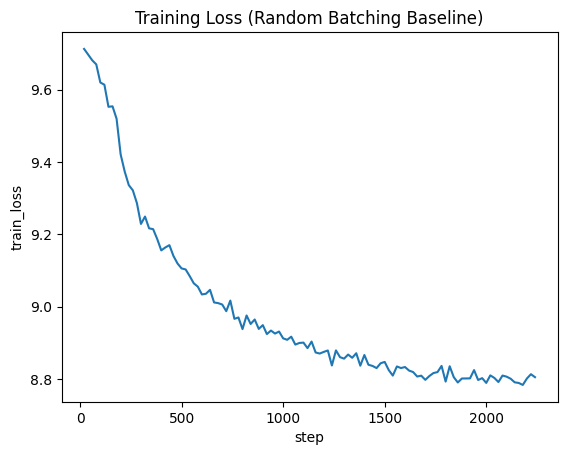

Saved: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/exp_003_baseline_random_lora/plots/loss_curve.png


In [ ]:
# Read metrics.jsonl and plot train loss
rows = []
with open(METRICS_JSONL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

# train loss events contain "loss"
loss_df = df[df["loss"].notna()] if "loss" in df.columns else pd.DataFrame()
plt.figure()
if not loss_df.empty:
    plt.plot(loss_df["step"], loss_df["loss"])
    plt.xlabel("step")
    plt.ylabel("train_loss")
    plt.title("Training Loss (Random Batching Baseline)")
else:
    plt.text(0.5, 0.5, "No loss events found", ha="center")
plt.savefig(LOSS_PLOT_PATH, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", LOSS_PLOT_PATH)

## 18) Run summary + append to experiment_logs.csv

In [ ]:
final_summary = {
    "exp_id": EXP_ID,
    "method": METHOD,
    "completed_at_utc": _now_utc(),
    "dataset_name": DATASET_NAME,
    "base_model": BASE_MODEL_DIRNAME,
    "seed": SEED,
    "train_size": len(train_tok),
    "eval_size": len(eval_tok),
    "final_train_metrics": train_result.metrics if hasattr(train_result, "metrics") else {},
    "final_eval_metrics": eval_result,
    "paths": {
        "run_root": RUN_ROOT,
        "adapter": adapter_out,
        "metrics_jsonl": METRICS_JSONL_PATH,
        "loss_plot": LOSS_PLOT_PATH,
        "run_manifest": RUN_MANIFEST_PATH,
    }
}

with open(RUN_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=2)

print("Wrote summary:", RUN_SUMMARY_PATH)

# ---- Append row to experiment_logs.csv (Google Sheets friendly) ----
row = {
    "exp_id": EXP_ID,
    "date_utc": final_summary["completed_at_utc"],
    "model": BASE_MODEL_DIRNAME,
    "dataset": DATASET_NAME,
    "method": METHOD,
    "batch_size": PER_DEVICE_BATCH,
    "grad_accum": GRAD_ACCUM,
    "lr": LEARNING_RATE,
    "epochs": EPOCHS,
    "seed": SEED,
    "train_loss": float(eval_result.get("eval_loss")) if isinstance(eval_result.get("eval_loss"), (int, float)) else None,
    "eval_loss": float(eval_result.get("eval_loss")) if isinstance(eval_result.get("eval_loss"), (int, float)) else None,
    "adapter_path": adapter_out,
    "run_root": RUN_ROOT,
    "notes": "baseline random batching LoRA",
}

# Create CSV if missing, else append
if os.path.exists(EXPERIMENT_CSV_PATH):
    df_csv = pd.read_csv(EXPERIMENT_CSV_PATH)
    df_csv = pd.concat([df_csv, pd.DataFrame([row])], ignore_index=True)
else:
    df_csv = pd.DataFrame([row])

df_csv.to_csv(EXPERIMENT_CSV_PATH, index=False)
print("Updated:", EXPERIMENT_CSV_PATH)

df_csv.tail(5)

Wrote summary: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/exp_003_baseline_random_lora/run_summary.json
Updated: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/experiment_logs/experiment_logs.csv


,exp_id,date_utc,model,dataset,method,batch_size,grad_accum,lr,epochs,seed,train_loss,eval_loss,adapter_path,run_root,notes
0,exp_003_baseline_random_lora,2026-03-05T18:11:41Z,flan-t5-small,dolly_small_1k,random_lora,8,1,0.00005,3,42,NaN,NaN,/content/drive/MyDrive/Compass_AI_ML_Research/...,/content/drive/MyDrive/Compass_AI_ML_Research/...,baseline random batching LoRA
1,exp_003_baseline_random_lora,2026-03-05T18:27:24Z,flan-t5-small,dolly_small_1k,random_lora,8,1,0.00005,20,42,8.55408,8.55408,/content/drive/MyDrive/Compass_AI_ML_Research/...,/content/drive/MyDrive/Compass_AI_ML_Research/...,baseline random batching LoRA
